In [1]:
import os
import copy
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models

from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [3]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"edersondacosta","key":"33d8c9bc05e847b306e10ee0b54b9883"}'}

In [4]:
!mkdir ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:58<00:00, 42.3MB/s]



In [6]:
!unzip -q chest-xray-pneumonia.zip

In [7]:
print(os.listdir('/content/chest_xray'))

['chest_xray', 'test', 'train', '__MACOSX', 'val']


In [8]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05,0.05)
    ),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [9]:
train_dataset = datasets.ImageFolder(
    root='/content/chest_xray/train',
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root='/content/chest_xray/train',
    transform=test_transform
)

In [10]:
test_dataset = datasets.ImageFolder(
    root='/content/chest_xray/test',
    transform=test_transform
)

In [11]:
print(train_dataset.classes)

['NORMAL', 'PNEUMONIA']


In [12]:
#Divisão Treino e Validação

from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

indices = list(range(len(train_dataset)))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=SEED,
    stratify=train_dataset.targets
)

train_dataset = Subset(
    train_dataset,
    train_indices
)

val_dataset = Subset(
    val_dataset,
    val_indices
)

In [13]:
#DataLoaders

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [14]:
# Arquitetura ResNet18 pré-treinada

model = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)

# Congelar todas as camadas
for param in model.parameters():
    param.requires_grad = False

# Substituir a última camada
num_features = model.fc.in_features

model.fc = nn.Sequential(

    nn.Linear(num_features, 128),

    nn.ReLU(),

    nn.Dropout(0.5),

    nn.Linear(128, 2)

)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s]


In [16]:
#Função de Perda

criterion = nn.CrossEntropyLoss()

In [17]:
#Otimizador - ADAM

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [18]:
#Épocas

NUM_EPOCHS = 30

In [19]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
import os

SAVE_DIR = "/content/drive/MyDrive/pneumonia/Experimento_3"

os.makedirs(SAVE_DIR, exist_ok=True)

In [21]:
import copy

best_val_loss = float('inf')
patience = 10
counter = 0

best_model_wts = copy.deepcopy(model.state_dict())

start_epoch = 0
start_epoch = 0

In [22]:
#Armazenar as métricas nas variáveis

train_losses = []
val_losses = []

train_accs = []
val_accs = []

In [23]:
checkpoint_path = os.path.join(SAVE_DIR, "checkpoint.pth")

if os.path.exists(checkpoint_path):

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    #Salvando o Histórico
    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])

    train_accs = checkpoint.get('train_accs', [])
    val_accs = checkpoint.get('val_accs', [])

    model.load_state_dict(
    checkpoint['model_state_dict']
    )



    optimizer.load_state_dict(
        checkpoint['optimizer_state_dict']
    )

    start_epoch = checkpoint['epoch'] + 1

    best_val_loss = checkpoint['best_val_loss']

    print(f"Treinamento retomado da época {start_epoch}")

else:

    print("Iniciando treinamento do zero")

Iniciando treinamento do zero


In [24]:
print("Treino:", len(train_dataset))
print("Validação:", len(val_dataset))
print("Teste:", len(test_dataset))

print(len(train_loader))
print(len(val_loader))

Treino: 4172
Validação: 1044
Teste: 624
66
17


In [25]:
# TREINAMENTO

NUM_EPOCHS = 30

for epoch in range(start_epoch, NUM_EPOCHS):





    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    #############################
    # VALIDAÇÃO
    #############################

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(
        f'Epoch [{epoch+1}/{NUM_EPOCHS}] | '
        f'Train Loss={train_loss:.10f} | '
        f'Val Loss={val_loss:.10f} | '
        f'Train Acc={train_acc:.10f} | '
        f'Val Acc={val_acc:.10f}'
    )

    ###################################
    # SALVAR CHECKPOINT
    ###################################

    checkpoint = {

    'epoch': epoch,

    'model_state_dict': model.state_dict(),

    'optimizer_state_dict': optimizer.state_dict(),

    'best_val_loss': best_val_loss,

    'train_losses': train_losses,

    'val_losses': val_losses,

    'train_accs': train_accs,

    'val_accs': val_accs

}


    torch.save(
        checkpoint,
        os.path.join(
            SAVE_DIR,
            "checkpoint.pth"
        )
    )

    ###################################
    # MELHOR MODELO
    ###################################

    if val_loss < best_val_loss:

      best_val_loss = val_loss

      best_model_wts = copy.deepcopy(
          model.state_dict()
      )

      torch.save(
          model.state_dict(),
          os.path.join(
              SAVE_DIR,
              "best_model.pth"
          )
      )

      counter = 0

      print(
          f"Melhor modelo salvo! "
          f"Val Loss = {val_loss:.4f}"
      )

    else:

        counter += 1

        print(
            f"Sem melhora ({counter}/{patience})"
        )

        if counter >= patience:

            print("Early Stopping")

            break

Epoch [1/30] | Train Loss=0.3580015812 | Val Loss=0.3553566994 | Train Acc=0.8458772771 | Val Acc=0.8342911877
Melhor modelo salvo! Val Loss = 0.3554
Epoch [2/30] | Train Loss=0.2012483963 | Val Loss=0.1299167207 | Train Acc=0.9185043145 | Val Acc=0.9454022989
Melhor modelo salvo! Val Loss = 0.1299
Epoch [3/30] | Train Loss=0.1943417032 | Val Loss=0.1562580646 | Train Acc=0.9220997124 | Val Acc=0.9406130268
Sem melhora (1/10)
Epoch [4/30] | Train Loss=0.1686968146 | Val Loss=0.2294592231 | Train Acc=0.9381591563 | Val Acc=0.9051724138
Sem melhora (2/10)
Epoch [5/30] | Train Loss=0.1724167643 | Val Loss=0.1405834117 | Train Acc=0.9307286673 | Val Acc=0.9444444444
Sem melhora (3/10)
Epoch [6/30] | Train Loss=0.1715128128 | Val Loss=0.1085496087 | Train Acc=0.9348034516 | Val Acc=0.9607279693
Melhor modelo salvo! Val Loss = 0.1085
Epoch [7/30] | Train Loss=0.1576833950 | Val Loss=0.1156692603 | Train Acc=0.9376797699 | Val Acc=0.9540229885
Sem melhora (1/10)
Epoch [8/30] | Train Loss=0.16

In [26]:
#Restaurando o melhor modelo
model = models.resnet18(
    weights=None
)

num_features = model.fc.in_features

model.fc = nn.Sequential(

    nn.Linear(num_features,128),

    nn.ReLU(),

    nn.Dropout(0.5),

    nn.Linear(128,2)

)

model = model.to(device)

model.load_state_dict(
    torch.load(
        os.path.join(
            SAVE_DIR,
            "best_model.pth"
        ),
        map_location=device
    )
)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [27]:
#Avalindo o conjunto de testes

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = outputs.max(1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

In [28]:
acc = accuracy_score(y_true,y_pred)
precision = precision_score(y_true,y_pred)
recall = recall_score(y_true,y_pred)
f1 = f1_score(y_true,y_pred)

print("Accuracy :",acc)
print("Precision:",precision)
print("Recall   :",recall)
print("F1-score :",f1)

Accuracy : 0.844551282051282
Precision: 0.8071278825995807
Recall   : 0.9871794871794872
F1-score : 0.8881199538638985


In [29]:
with open("/content/drive/MyDrive/pneumonia/Experimento_3/metricas_BaseLine.txt", "w") as f:

    f.write(f"Accuracy : {acc:.6f}\n")
    f.write(f"Precision: {precision:.6f}\n")
    f.write(f"Recall   : {recall:.6f}\n")
    f.write(f"F1-score : {f1:.6f}\n")

print("Métricas salvas em metricas.txt")

Métricas salvas em metricas.txt


In [30]:
import pandas as pd

resultados = pd.DataFrame({

    "Modelo": ["CNN Baseline"],

    "Accuracy": [acc],

    "Precision": [precision],

    "Recall": [recall],

    "F1-score": [f1]

})

resultados.to_csv(
    os.path.join(SAVE_DIR, "metricas.csv"),
    index=False
)

print("Métricas salvas em metricas.csv")

Métricas salvas em metricas.csv


In [31]:
report = classification_report(
    y_true,
    y_pred,
    target_names=['NORMAL', 'PNEUMONIA']
)

print(report)

with open(
    "/content/drive/MyDrive/pneumonia/Experimento_3/classification_report_BaseLine.txt",
    "w"
) as f:

    f.write("CNN Baseline\n")
    f.write("="*60 + "\n\n")

    f.write(f"Accuracy : {acc:.6f}\n")
    f.write(f"Precision: {precision:.6f}\n")
    f.write(f"Recall   : {recall:.6f}\n")
    f.write(f"F1-score : {f1:.6f}\n\n")

    f.write("="*60 + "\n")
    f.write("Classification Report\n")
    f.write("="*60 + "\n\n")

    f.write(report)

print("Classification report salvo com sucesso.")

              precision    recall  f1-score   support

      NORMAL       0.97      0.61      0.75       234
   PNEUMONIA       0.81      0.99      0.89       390

    accuracy                           0.84       624
   macro avg       0.89      0.80      0.82       624
weighted avg       0.87      0.84      0.83       624

Classification report salvo com sucesso.


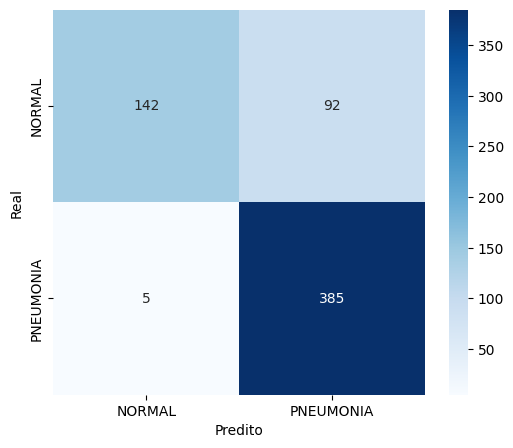

In [32]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NORMAL','PNEUMONIA'],
    yticklabels=['NORMAL','PNEUMONIA']
)

plt.xlabel('Predito')
plt.ylabel('Real')


plt.savefig(
    "/content/drive/MyDrive/pneumonia/Experimento_3/matriz_confusao_BaseLine.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

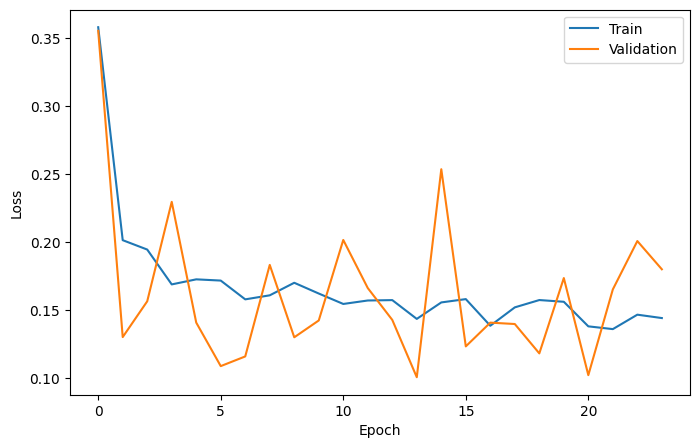

In [33]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label='Train')
plt.plot(val_losses,label='Validation')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()


plt.savefig(
    "/content/drive/MyDrive/pneumonia/Experimento_3/loss_curve_BaseLine.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


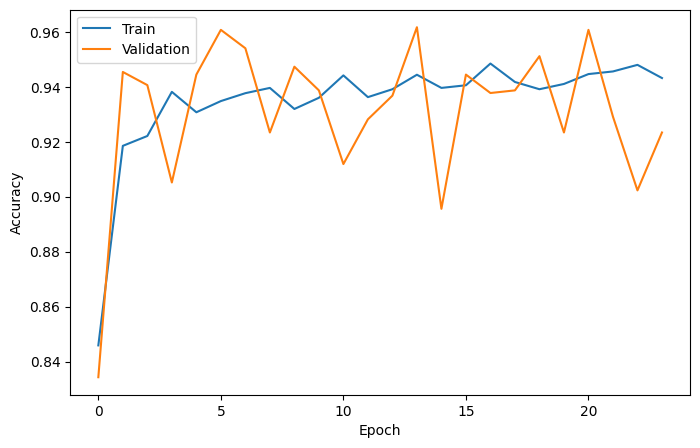

In [34]:
plt.figure(figsize=(8,5))

plt.plot(train_accs,label='Train')
plt.plot(val_accs,label='Validation')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.savefig(
    "/content/drive/MyDrive/pneumonia/Experimento_3/accuracy_curve_BaseLine.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()